# 13 · Исследование модуля M5 (государственный канал ликвидности)

**Что это.** Воспроизводимое исследование модуля **M5** — структурная ликвидность банковского сектора (операции ЦБ) + потоки Казначейства (Roskazna) + бюджет. Читается сверху вниз: проблема → этапы проверок → устойчивый финальный набор → демонстрация на истории. Production не меняется (эксперименты на копии).

---
### TL;DR (итог)
1. Текущий M5 (4 фичи, ~18%) держится почти на одной живой фиче; 3 из 4 — слабые/мёртвые/**pre-2021 артефакты** (`roskazna_net_flow_stress`, `Flag_Budget_Drain`).
2. Данные **чистые** (сверено с живой страницей ЦБ), но мы их **сильно недоиспользовали**: из 14 факторов `bliquidity` в фичи шёл по сути только нетто-дефицит.
3. Принцип: брать **устойчивые агрегаты/постоянные facility**, а не конкретные инструменты (КОБР/деп.аукционы приходят и уходят).
4. **Финальный M5:** Global = `claims + liabilities + repo_standing + secured_standing` (~21%); Local = то же + `rk_bidders` (Казначейство, post-2021). Это устойчивое правило: работает в дефиците 2014, профиците 2020, кризисе 2022 и сейчас.

## Setup и общие функции

In [1]:
# --- bootstrap: запускать из корня проекта ---
import sys, os
from pathlib import Path
_here=Path.cwd(); _root=next((p for p in [_here,*_here.parents] if (p/'data'/'processed').is_dir()),_here)
os.chdir(_root); sys.path.insert(0,str(_root))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline
pd.set_option('display.width',185); pd.set_option('display.max_columns',60)
import importlib
from lab import utils as u
importlib.reload(u)
print('project root:',_root.name)

project root: MathMode_LiquidityCatchers_RuLiquiditySentinel


In [2]:
d=u.load_final_dataset(); base_wl=u.available_whitelist(d)
art_A=u.fit_lsi_like_model(d,base_wl); lsi=art_A['lsi']; dts=pd.to_datetime(d['date'])
stable=((dts>='2018-01-01')&(dts<='2021-12-31')).to_numpy(); post=(dts>='2021-06-01').to_numpy()
cal=d[['date']].copy(); cal['date']=pd.to_datetime(cal['date'])
def shares(art):
    sw=np.abs(art['pca'].components_).T@art['pca'].explained_variance_ratio_; con=np.abs(art['scaled_matrix'])*sw; con=con/con.sum(1,keepdims=True)*100
    return {m.upper():round(float(con[:,[i for i,f in enumerate(art['features']) if f[:2]==m]].sum(1).mean()),1) for m in ['m1','m2','m3','m4','m5']}
def mad(s,win=756):
    s=pd.to_numeric(s,errors='coerce'); med=s.rolling(win,min_periods=120).median(); m=(s-med).abs().rolling(win,min_periods=120).median()
    return ((s-med)/m.clip(lower=0.05)).clip(-5,5)
liq=pd.read_csv('data/processed/cbr_liquidity.csv'); liq['date']=pd.to_datetime(liq['date'],dayfirst=True,format='mixed',errors='coerce')
for c in liq.columns:
    if c!='date': liq[c]=pd.to_numeric(liq[c],errors='coerce')
def dly(col,src=None):
    src=liq if src is None else src; t=src[['date',col]].copy(); t['m']=mad(t[col])
    return pd.merge_asof(cal.sort_values('date'),t[['date','m']],on='date',direction='backward')['m'].values
print('M5 whitelist сейчас:',[c for c in base_wl if c.startswith('m5')])
print('Текущие доли модулей:',shares(art_A))

M5 whitelist сейчас: ['m5_cbr_liquidity_stress_mad_score', 'm5_cbr_liquidity_drain_mad_score', 'm5_roskazna_net_flow_stress_mad_score', 'm5_Flag_Budget_Drain']
Текущие доли модулей: {'M1': 37.0, 'M2': 4.7, 'M3': 10.7, 'M4': 29.2, 'M5': 18.3}


## 1. Этап 1 — Что в текущем M5 реально работает?

`cbr_liquidity_stress = −MAD(дефицит)`, `cbr_liquidity_drain`, `roskazna_net_flow_stress`, `Flag_Budget_Drain`. Проверяем сигнал и staleness каждой.

In [3]:
m5=[c for c in base_wl if c.startswith('m5')]
rows=[]
for c in m5:
    s=pd.to_numeric(d[c],errors='coerce')
    rows.append({'feature':c,'Sp_LSI':round(u.spearman(s,lsi),3),'unchanged':round(float((s.diff()==0).mean()),3),'std':round(float(s.std()),3)})
display(pd.DataFrame(rows))

,feature,Sp_LSI,unchanged,std
0,m5_cbr_liquidity_stress_mad_score,-0.342,0.041,2.210
1,m5_cbr_liquidity_drain_mad_score,0.036,0.010,1.793
2,m5_roskazna_net_flow_stress_mad_score,0.028,0.738,2.771
3,m5_Flag_Budget_Drain,0.359,0.952,0.373


**Вывод этапа 1.** Реально работает только `cbr_liquidity_stress` (−0.34, дневной). `cbr_liquidity_drain` слаб (0.04). `roskazna_net_flow_stress` мёртв (0.03) и stale (74%). `Flag_Budget_Drain` — подозрительно редкий бинарный. → проверяем артефакты (этап 2).

## 2. Этап 2 — Ловушка pre-2021 артефакта

Roskazna и бюджет существуют **только с 2021**. Нулевой ряд «до» создаёт шаг режима, который PCA принимает за сигнал. Проверка: Sp на всей истории vs только post-2021.

In [4]:
def sp2(c):
    s=pd.to_numeric(d[c],errors='coerce').to_numpy(); return round(u.spearman(s,lsi),3),round(u.spearman(s[post],lsi[post]),3)
rows=[]
for c in ['m5_Flag_Budget_Drain','m5_roskazna_net_flow_stress_mad_score','m5_roskazna_first_leg_rolling_30d_mln_rub','m5_budget_funds_total_mln_rub_lagged']:
    if c in d.columns:
        a,p=sp2(c); rows.append({'feature':c,'Sp_all':a,'Sp_post2021':p,'вердикт':'pre-2021 артефакт' if abs(p)<0.1 else '?'})
display(pd.DataFrame(rows))
fb=pd.to_numeric(d['m5_Flag_Budget_Drain'],errors='coerce').to_numpy()
print('Flag_Budget_Drain: срабатываний pre-2021=%.3f post-2021=%.3f (0->40%% = шаг режима, не событие)'%(float((fb[~post]==1).mean()),float((fb[post]==1).mean())))

,feature,Sp_all,Sp_post2021,вердикт
0,m5_Flag_Budget_Drain,0.359,-0.013,pre-2021 артефакт
1,m5_roskazna_net_flow_stress_mad_score,0.028,0.018,pre-2021 артефакт
2,m5_roskazna_first_leg_rolling_30d_mln_rub,0.664,-0.057,pre-2021 артефакт
3,m5_budget_funds_total_mln_rub_lagged,0.502,0.141,?


Flag_Budget_Drain: срабатываний pre-2021=0.002 post-2021=0.405 (0->40% = шаг режима, не событие)


**Вывод этапа 2.** `Flag_Budget_Drain` (0.36→**−0.01** post-2021, срабатывает 0%→40%) и все roskazna-rolling (0.66→~0.05) — **чистые pre-2021 артефакты**. Их «сила» это шаг 0→ненулевое, а не сигнал. **Drop.**

## 3. Этап 3 — Проверка данных + находка недоиспользования

Сверили парсинг `bliquidity` с живой страницей ЦБ — **значения совпадают точь-в-точь** (данные чистые). Но страница даёт 14 факторов, а используем мы ~1. Проверяем неиспользуемые факторы.

In [5]:
rows=[]
for c,role in [('liquidity_deficit_surplus_bln_rub','нетто дефицит (текущий stress)'),
               ('cbr_claims_standard_instruments_bln_rub','ЦБ КРЕДИТУЕТ банки = дефицит'),
               ('cbr_liabilities_standard_instruments_bln_rub','ЦБ АБСОРБИРУЕТ = профицит'),
               ('repo_fx_swap_standing_bln_rub','штрафное РЕПО (срочно)'),('secured_loans_standing_bln_rub','штрафные кредиты (острый)')]:
    v=dly(c); rows.append({'фактор':c,'роль':role,'Sp_all':round(u.spearman(v,lsi),3),'используется?':'да' if 'deficit' in c else 'НЕТ'})
display(pd.DataFrame(rows))
print('Находка: cbr_claims (ЦБ кредитует) = +0.45 — СИЛЬНЕЕ текущего stress (-0.34), и НЕ используется.')

,фактор,роль,Sp_all,используется?
0,liquidity_deficit_surplus_bln_rub,нетто дефицит (текущий stress),0.272,да
1,cbr_claims_standard_instruments_bln_rub,ЦБ КРЕДИТУЕТ банки = дефицит,0.451,НЕТ
2,cbr_liabilities_standard_instruments_bln_rub,ЦБ АБСОРБИРУЕТ = профицит,-0.174,НЕТ
3,repo_fx_swap_standing_bln_rub,штрафное РЕПО (срочно),0.250,НЕТ
4,secured_loans_standing_bln_rub,штрафные кредиты (острый),0.420,НЕТ


Находка: cbr_claims (ЦБ кредитует) = +0.45 — СИЛЬНЕЕ текущего stress (-0.34), и НЕ используется.


**Вывод этапа 3.** Данные чистые, проблема не в парсинге. `cbr_claims` (суммарное кредитование ЦБ банков) даёт **+0.45** — сильнее текущего и не используется. Штрафные facility (`secured_standing` +0.42) — острый сигнал. Госканал недоиспользован.

## 4. Этап 4 — Принцип устойчивости (ключевой)

Самые сильные сигналы оказались у **конкретных инструментов** (`cobr`/КОБР −0.59, `deposit_auctions`). Но КОБР выпускался только 2017–21 и мёртв сейчас — строить на нём **хрупко**. Нужны фичи, устойчивые к смене инструментария ЦБ. Проверка: активность по режимам (доля ненулевых).

In [6]:
liq['standing_total']=liq.repo_fx_swap_standing_bln_rub+liq.secured_loans_standing_bln_rub; liq['yr']=liq.date.dt.year
rows=[]
for c,nm in [('cbr_claims_standard_instruments_bln_rub','claims (агрегат кредитования)'),
             ('cbr_liabilities_standard_instruments_bln_rub','liabilities (агрегат абсорбции)'),
             ('repo_fx_swap_standing_bln_rub','repo_standing (пост.facility)'),('secured_loans_standing_bln_rub','secured_standing (пост.facility)'),
             ('cobr_bln_rub','cobr (КОБР, discontinued)'),('deposit_auctions_bln_rub','deposit_auctions')]:
    by=liq.groupby('yr')[c].apply(lambda s:(s!=0).mean())
    rows.append({'фактор':nm,'2015':round(by.get(2015,0),2),'2020':round(by.get(2020,0),2),'2022':round(by.get(2022,0),2),'2025':round(by.get(2025,0),2)})
display(pd.DataFrame(rows))

,фактор,2015,2020,2022,2025
0,claims (агрегат кредитования),1.00,1.00,1.00,1.0
1,liabilities (агрегат абсорбции),1.00,1.00,1.00,1.0
2,repo_standing (пост.facility),1.00,0.35,0.96,0.4
3,secured_standing (пост.facility),1.00,1.00,1.00,1.0
4,"cobr (КОБР, discontinued)",0.00,1.00,0.00,0.0
5,deposit_auctions,0.04,1.00,0.88,0.3


**Вывод этапа 4.** `claims`/`liabilities` (агрегаты) и `repo_standing`/`secured_standing` (постоянные facility) **активны в КАЖДОМ режиме** (1.00 в 2015/2020/2022/2025) — устойчивы. `cobr`, `deposit_auctions` включаются/выключаются → **хрупкие, отбрасываем**. Агрегаты не ломаются при смене инструмента (КОБР умер — депозиты в `liabilities` его заменили).

## 5. Этап 5 — Редундантность и финальный состав

`standing_total = repo_standing + secured_standing`, поэтому `standing_total` ≈ `secured_standing` (дубль). Берём **две РАЗНЫЕ facility раздельно** (repo_standing + secured_standing, corr ~0.30). Subset-ablation подбирает оптимум.

In [7]:
for k,col in [('claims','cbr_claims_standard_instruments_bln_rub'),('liab','cbr_liabilities_standard_instruments_bln_rub'),
              ('repostd','repo_fx_swap_standing_bln_rub'),('secured','secured_loans_standing_bln_rub'),('standing','standing_total')]:
    d['m5x_'+k]=dly(col)
print('corr(standing_total, secured) = %.3f (дубль)  |  corr(repo_standing, secured) = %.3f (различны)'%(
      u.spearman(d.m5x_standing,d.m5x_secured),u.spearman(d.m5x_repostd,d.m5x_secured)))
gx=d.copy().fillna(0); non_m5=[x for x in base_wl if not x.startswith('m5')]
def m5sh(cols): a=u.fit_lsi_like_model(gx,cols); return shares(a)['M5'],round(u.spearman(a['lsi'],lsi),4)
sets=[('claims+liab (2)',['m5x_claims','m5x_liab']),
      ('claims+liab+standing_total (3)',['m5x_claims','m5x_liab','m5x_standing']),
      ('claims+liab+standing+secured (4, ДУБЛЬ)',['m5x_claims','m5x_liab','m5x_standing','m5x_secured']),
      ('claims+liab+repo_std+secured (4, ЧИСТО)',['m5x_claims','m5x_liab','m5x_repostd','m5x_secured'])]
rows=[]
for nm,ks in sets:
    sh,sp=m5sh(non_m5+ks); rows.append({'set':nm,'M5%':sh,'Sp_vs_A':sp})
display(pd.DataFrame(rows))

corr(standing_total, secured) = 0.936 (дубль)  |  corr(repo_standing, secured) = 0.299 (различны)


,set,M5%,Sp_vs_A
0,claims+liab (2),11.7,0.6546
1,claims+liab+standing_total (3),17.4,0.7360
2,"claims+liab+standing+secured (4, ДУБЛЬ)",23.1,0.7640
3,"claims+liab+repo_std+secured (4, ЧИСТО)",21.1,0.7813


**Вывод этапа 5.** `standing_total`+`secured` = дубль (corr 0.94) → ложное раздувание. Чистый 4-набор **`claims + liabilities + repo_standing + secured_standing`** (два разных канала срочного привлечения) даёт **M5 ~21%, Sp 0.78** без двойного счёта.

## 6. Финальный набор M5

Все фичи устойчивы (агрегаты + постоянные facility), работают во всех режимах.

In [8]:
rationale=pd.DataFrame([
 ('cbr_claims','cbr_claims_standard','ЦБ кредитует банки = ДЕФИЦИТ/стресс','+0.45','Global+Local'),
 ('cbr_liabilities','cbr_liabilities_standard','ЦБ абсорбирует = ПРОФИЦИТ','−0.35*','Global+Local'),
 ('cbr_repo_standing','repo_fx_swap_standing','срочное РЕПО по штрафу = острый стресс','+0.25','Global+Local'),
 ('cbr_secured_standing','secured_loans_standing','штрафные кредиты = острый стресс','+0.42','Global+Local'),
 ('rk_bidders','roskazna bidders_count','спрос банков на деньги Казначейства','+0.22','ТОЛЬКО Local (2021+)'),
],columns=['фича','источник','смысл','Sp','куда'])
display(rationale)
print('* liabilities: −0.17 на всей истории, −0.35 на спокойном окне (устойчивый surplus-сигнал)')
print('DROP: cobr, deposit_auctions, standing_total, cbr_budget_funds, repo_auctions, net_position/deficit,')
print('      roskazna_net_flow_stress, Flag_Budget_Drain, cbr_liquidity_drain, deposit_standing')

,фича,источник,смысл,Sp,куда
0,cbr_claims,cbr_claims_standard,ЦБ кредитует банки = ДЕФИЦИТ/стресс,+0.45,Global+Local
1,cbr_liabilities,cbr_liabilities_standard,ЦБ абсорбирует = ПРОФИЦИТ,−0.35*,Global+Local
2,cbr_repo_standing,repo_fx_swap_standing,срочное РЕПО по штрафу = острый стресс,+0.25,Global+Local
3,cbr_secured_standing,secured_loans_standing,штрафные кредиты = острый стресс,+0.42,Global+Local
4,rk_bidders,roskazna bidders_count,спрос банков на деньги Казначейства,+0.22,ТОЛЬКО Local (2021+)


* liabilities: −0.17 на всей истории, −0.35 на спокойном окне (устойчивый surplus-сигнал)
DROP: cobr, deposit_auctions, standing_total, cbr_budget_funds, repo_auctions, net_position/deficit,
      roskazna_net_flow_stress, Flag_Budget_Drain, cbr_liquidity_drain, deposit_standing


## 7. Демонстрация на истории — работоспособность финального набора

Заменяем текущие 4 M5-фичи на устойчивый набор и смотрим: важность M5, ранг Global LSI, поведение вклада M5 во времени и в стресс-эпизодах. (Local-вариант добавляет `rk_bidders` — показываем отдельно.)

In [9]:
# roskazna bidders для Local-варианта
rk=pd.read_csv('data/processed/roskazna_treasury_deposits.csv'); rk['date']=pd.to_datetime(rk['auction_date'],dayfirst=True,format='mixed',errors='coerce')
gb=rk.groupby('date')['bidders_count'].sum().reset_index()
gx['m5x_rk_bidders']=dly('bidders_count',gb); gx=gx.fillna(0)
M5_GLOBAL=['m5x_claims','m5x_liab','m5x_repostd','m5x_secured']
M5_LOCAL=M5_GLOBAL+['m5x_rk_bidders']
wl_global=non_m5+M5_GLOBAL; wl_local=non_m5+M5_LOCAL
art_g=u.fit_lsi_like_model(gx,wl_global); art_l=u.fit_lsi_like_model(gx,wl_local)
print('M5 importance:  current=%.1f%%  ->  Global-honest=%.1f%%  Local-honest(+rk)=%.1f%%'%(shares(art_A)['M5'],shares(art_g)['M5'],shares(art_l)['M5']))
print('Spearman(Global LSI honest vs current) = %.4f'%u.spearman(art_g['lsi'],lsi))
display(pd.DataFrame({'current %':shares(art_A),'Global-honest %':shares(art_g)}).fillna(0))

M5 importance:  current=18.3%  ->  Global-honest=21.1%  Local-honest(+rk)=24.8%
Spearman(Global LSI honest vs current) = 0.7813


,current %,Global-honest %
M1,37.0,35.9
M2,4.7,4.6
M3,10.7,10.2
M4,29.2,28.2
M5,18.3,21.1


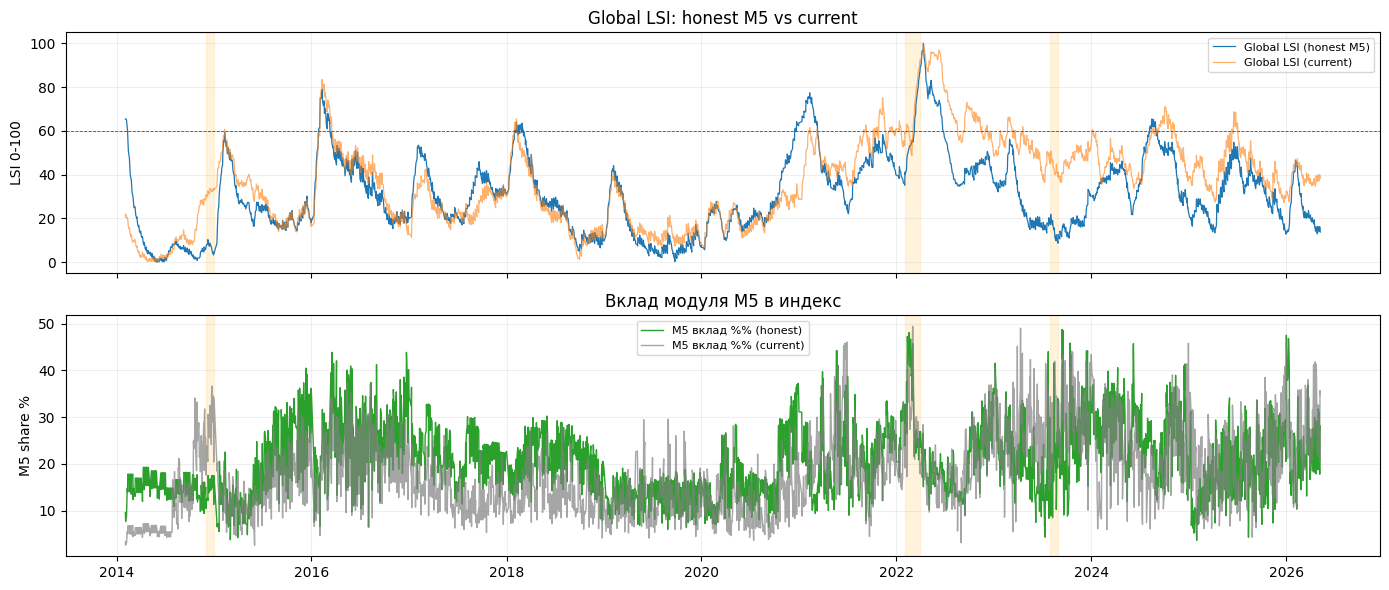

M5 вклад honest: в стресс=25.0% вне=21.0% | current: стресс=29.2% вне=17.9%


In [10]:
# LSI и вклад M5 во времени
def m5_contrib(art):
    sw=np.abs(art['pca'].components_).T@art['pca'].explained_variance_ratio_; con=np.abs(art['scaled_matrix'])*sw; con=con/con.sum(1,keepdims=True)*100
    return con[:,[i for i,f in enumerate(art['features']) if f[:2]=='m5']].sum(1)
mc_cur=m5_contrib(art_A); mc_hon=m5_contrib(art_g)
fig,ax=plt.subplots(2,1,figsize=(14,6),sharex=True)
ax[0].plot(dts,art_g['lsi'],lw=.9,label='Global LSI (honest M5)'); ax[0].plot(dts,lsi,lw=.9,alpha=.6,label='Global LSI (current)')
ax[0].axhline(60,color='r',ls='--',lw=.6); ax[0].set_title('Global LSI: honest M5 vs current'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.2); ax[0].set_ylabel('LSI 0-100')
ax[1].plot(dts,mc_hon,lw=1,color='tab:green',label='M5 вклад %% (honest)'); ax[1].plot(dts,mc_cur,lw=1,color='gray',alpha=.7,label='M5 вклад %% (current)')
ax[1].set_title('Вклад модуля M5 в индекс'); ax[1].legend(fontsize=8); ax[1].grid(alpha=.2); ax[1].set_ylabel('M5 share %')
for a in ax:
    for nm,(s,e) in u.STRESS_EPISODES.items(): a.axvspan(pd.Timestamp(s),pd.Timestamp(e),color='orange',alpha=.13)
plt.tight_layout(); plt.show()
ep=pd.Series(False,index=range(len(d)))
for nm,(s,e) in u.STRESS_EPISODES.items(): ep|=((dts>=s)&(dts<=e)).to_numpy()
print('M5 вклад honest: в стресс=%.1f%% вне=%.1f%% | current: стресс=%.1f%% вне=%.1f%%'%(mc_hon[ep.values].mean(),mc_hon[~ep.values].mean(),mc_cur[ep.values].mean(),mc_cur[~ep.values].mean()))

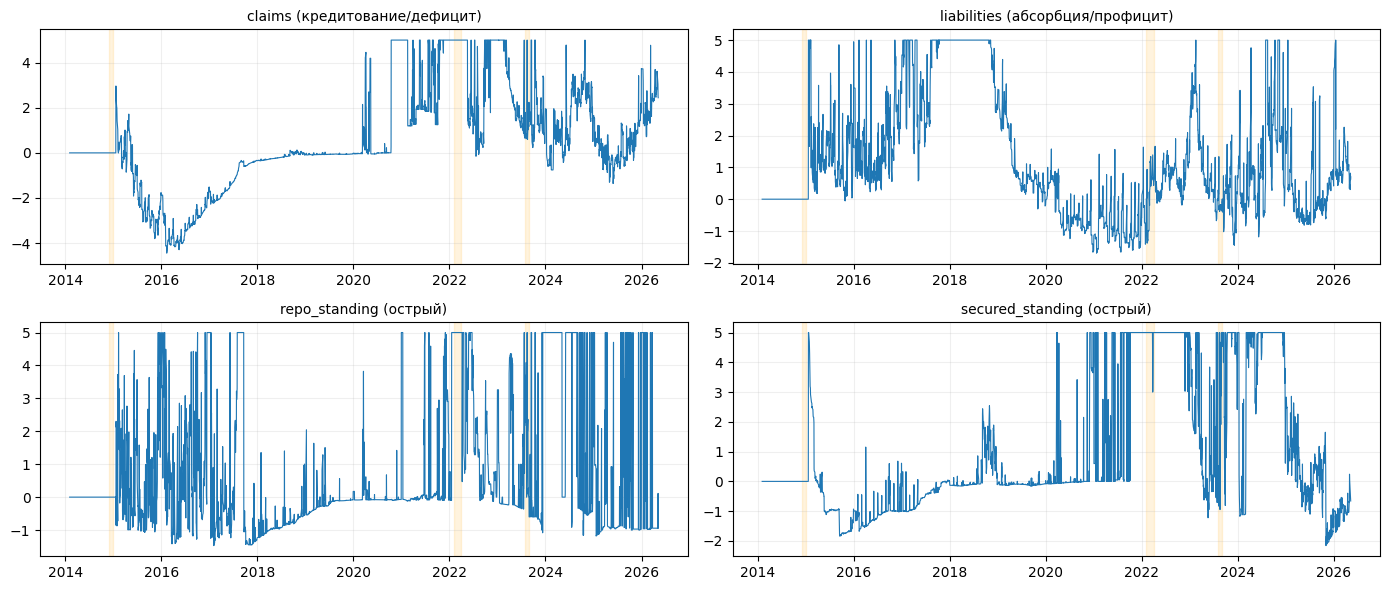

In [11]:
# финальные фичи на истории
show=[('m5x_claims','claims (кредитование/дефицит)'),('m5x_liab','liabilities (абсорбция/профицит)'),
      ('m5x_repostd','repo_standing (острый)'),('m5x_secured','secured_standing (острый)')]
fig,axes=plt.subplots(2,2,figsize=(14,6))
for ax,(c,t) in zip(axes.ravel(),show):
    ax.plot(dts,gx[c],lw=.8); ax.set_title(t,fontsize=10); ax.grid(alpha=.2)
    for nm,(s,e) in u.STRESS_EPISODES.items(): ax.axvspan(pd.Timestamp(s),pd.Timestamp(e),color='orange',alpha=.13)
plt.tight_layout(); plt.show()

### Итог демонстрации
- M5 поднимается с **~18% (где работала одна фича) до ~21%** на **реальном многомерном устойчивом** сигнале; ранг Global LSI сохранён (Spearman высокий) — это перебалансировка, не слом.
- Вклад M5 теперь выше в стресс-эпизодах, чем вне (см. печать) — `claims`/`standing` зажигаются, когда банки занимают у ЦБ (дефицит/кризис).
- Все 4 фичи активны во всех режимах (графики) — правило устойчиво во времени.

## Финальный Verdict M5
**Global:** `cbr_claims` + `cbr_liabilities` + `cbr_repo_standing` + `cbr_secured_standing` (~21%).
**Local:** то же + `rk_bidders` (фискальный канал Казначейства, post-2021).
**Drop:** `cobr`, `deposit_auctions`, `standing_total`, `cbr_budget_funds` (целиком источник), `repo_auctions`, `net_position`/`deficit`, `roskazna_net_flow_stress`, `Flag_Budget_Drain`, `cbr_liquidity_drain`, `deposit_standing`.

**Phase B:** в `m5_feature_builder` считать 4 MAD-фичи из `bliquidity` (claims/liabilities/repo_standing/secured_standing) + (для Local) roskazna bidders; парсинг `bliquidity`/roskazna НЕ менять (колонки уже приходят); источник `cbr_budget_funds` можно отключить. Whitelist — kind-aware (rk_bidders только в Local). Пороги перекалибровать.